In [23]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, Literal
import math

In [24]:
class QuadraticState(TypedDict):
    
    a : int
    c : int
    b : int
    equation: str
    discriminant :float
    result: str

In [25]:
def display_equation(state: QuadraticState):
    equation = f'{state['a']}x^2 + {state['b']}x + {state['c']} = 0'
    state['equation'] = equation
    return {'equation': equation}

In [ ]:
def calculate_discriminant(state: QuadraticState):
    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = math.sqrt(b**2 - (4 * a * c))
    state['discriminant'] = discriminant
    return {'discriminant': discriminant}

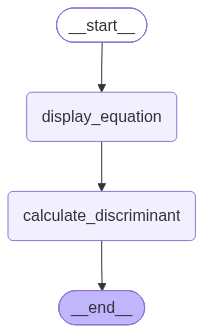

In [27]:
graph = StateGraph(QuadraticState)
graph.add_node('display_equation', display_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)

graph.add_edge(START, "display_equation")
graph.add_edge('display_equation', 'calculate_discriminant')
graph.add_edge('calculate_discriminant', END)
workflow = graph.compile()
workflow

In [ ]:
initial_state = {'a': 4, 'b': 3, 'c': 2}
final_state = workflow.invoke(initial_state)
print(final_state)

ValueError: math domain error